# Capacitated Vehicle Routing Problem with Time Windows (CVRPTW)
## Pharmaceutical Last-Mile Delivery — Stochastic Optimization Analysis

---

**Dataset:** Real-world pharmaceutical distribution network (Zenodo record 15672291)  
**Solver:** Google OR-Tools CP routing (guided local search)  
**Focus:** Stochastic travel times · Robustness under uncertainty · Scenario analysis

---

## 1. Problem Definition

A pharmaceutical distributor operates a fleet of refrigerated vans from a central depot to **78 hospital and pharmacy nodes** in the Attica region (Greece). Each customer has:

- A **weight** and **volume** demand
- A **service time** (unloading duration)
- A **time window** `[EAT, LAT]` — the earliest and latest acceptable arrival

Travel time is **stochastic**, characterised by three scenarios drawn from GPS trajectory data:

| Scenario | Interpretation |
|---|---|
| Optimistic | Free-flow traffic |
| Most-likely | Typical weekday conditions |
| Pessimistic | Peak-hour congestion |

**Decision:** Assign customers to vehicles and sequence deliveries to minimise total travel time while satisfying all capacity and time-window constraints.

## 2. Mathematical Formulation

### Sets and parameters

$$N = \{0, 1, \ldots, n\}, \quad 0 = \text{depot},\quad K = \{1,\ldots,m\} = \text{vehicles}$$

$$\tau_{ij} = \text{travel time on arc } (i,j),\quad w_i, v_i = \text{weight, volume demand at node } i$$

$$s_i = \text{service time},\quad [a_i, l_i] = \text{time window},\quad W, V = \text{vehicle capacities}$$

### Decision variables

$$x_{ijk} \in \{0,1\} \quad \text{vehicle } k \text{ traverses arc } (i,j)$$

$$t_i \geq 0 \quad \text{arrival time at node } i$$

### Objective

$$\min \sum_{k \in K} \sum_{(i,j) \in A} \tau_{ij} \cdot x_{ijk}$$

### Constraints

**Visit each customer exactly once:**
$$\sum_{k \in K} \sum_{j \in N} x_{ijk} = 1 \qquad \forall\, i \in N \setminus \{0\}$$

**Flow conservation:**
$$\sum_{j \in N} x_{ijk} = \sum_{j \in N} x_{jik} \qquad \forall\, i \in N,\; k \in K$$

**Weight and volume capacity:**
$$\sum_{i \in N} w_i \sum_{j \in N} x_{ijk} \leq W \qquad \forall\, k \in K$$
$$\sum_{i \in N} v_i \sum_{j \in N} x_{ijk} \leq V \qquad \forall\, k \in K$$

**Time propagation (with service time):**
$$t_j \geq t_i + s_i + \tau_{ij} - M(1 - x_{ijk}) \qquad \forall\, (i,j),\; k \in K$$

**Time window:**
$$a_i \leq t_i \leq l_i \qquad \forall\, i \in N$$

### Stochastic extension — PERT model

Travel time $\tilde{\tau}_{ij}$ is modelled as a PERT (four-parameter Beta) random variable:

$$\mu_{ij} = \frac{a_{ij} + 4m_{ij} + b_{ij}}{6}, \qquad \sigma^2_{ij} = \left(\frac{b_{ij} - a_{ij}}{6}\right)^2$$

where $a, m, b$ are the optimistic, most-likely, and pessimistic travel times respectively.  
Arrival-time variance is propagated additively along a route:

$$\sigma^2_{\text{arrival at node } p} = \sum_{\text{arcs on route up to } p} \sigma^2_{ij}$$

The probability of late delivery at node $i$ is then:

$$P(t_i > l_i) = 1 - \Phi\!\left(\frac{l_i - \mu_i^{\text{arrival}}}{\sigma_i^{\text{arrival}}}\right)$$

## 3. Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Project modules
from src.data_loader     import load_orders, load_day, orders_eda
from src.cvrptw_solver   import solve, CVRPTWSolver, DEFAULT_NUM_VEHICLES, DEFAULT_MAX_WEIGHT_KG, DEFAULT_MAX_VOLUME_M3
from src.stochastic_analysis  import (
    solve_all_scenarios, scenario_kpi_table, route_overlap_matrix,
    lateness_by_customer, compute_pert_statistics
)
from src.robustness_analysis  import (
    customer_delay_risk, route_stability_scores,
    arc_uncertainty_report, route_arrival_deviation
)
from src.scenario_experiments import run_all_experiments
from src.clustering           import (
    extract_node_features, choose_k, cluster_customers,
    solve_decomposed, compare_decomposed_vs_global
)
from src.visualizations import (
    plot_routes, plot_scenario_kpis, plot_arrival_vs_window,
    plot_delay_risk, plot_stability_scores, plot_experiment,
    plot_silhouette, plot_cluster_assignment, plot_kpi_dashboard,
    plot_time_matrix_heatmap, plot_pert_distribution
)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Environment ready.')

Environment ready.


## 4. Data Loading & Exploratory Analysis

In [2]:
# Load customer orders (shared across all days)
orders = load_orders()
print('=== Orders Dataset ===')
orders_eda(orders)

=== Orders Dataset ===
Customers        : 78
Total weight     : 1880.5 kg
Total volume     : 9.0200 m³
Weight range     : [0.070, 305.190] kg
Volume range     : [0.00085, 1.95178] m³
Service times    : [np.int64(4), np.int64(8), np.int64(12)] min
Time windows (LAT): [np.int64(180), np.int64(300), np.int64(360)] min
  LAT= 180 min : 15 customers
  LAT= 300 min : 47 customers
  LAT= 360 min : 16 customers


In [3]:
orders.describe().round(3)

,NODE_ID,WEIGHT,VOLUME,SERVICE_TIME,EAT,LAT
count,78.000,78.000,78.000,78.000,78.0,78.000
mean,39.500,24.109,0.116,6.359,0.0,289.231
std,22.661,44.910,0.261,3.187,0.0,58.615
min,1.000,0.070,0.001,4.000,0.0,180.000
25%,20.250,1.790,0.006,4.000,0.0,300.000
50%,39.500,9.563,0.043,4.000,0.0,300.000
75%,58.750,28.593,0.097,8.000,0.0,300.000
max,78.000,305.190,1.952,12.000,0.0,360.000


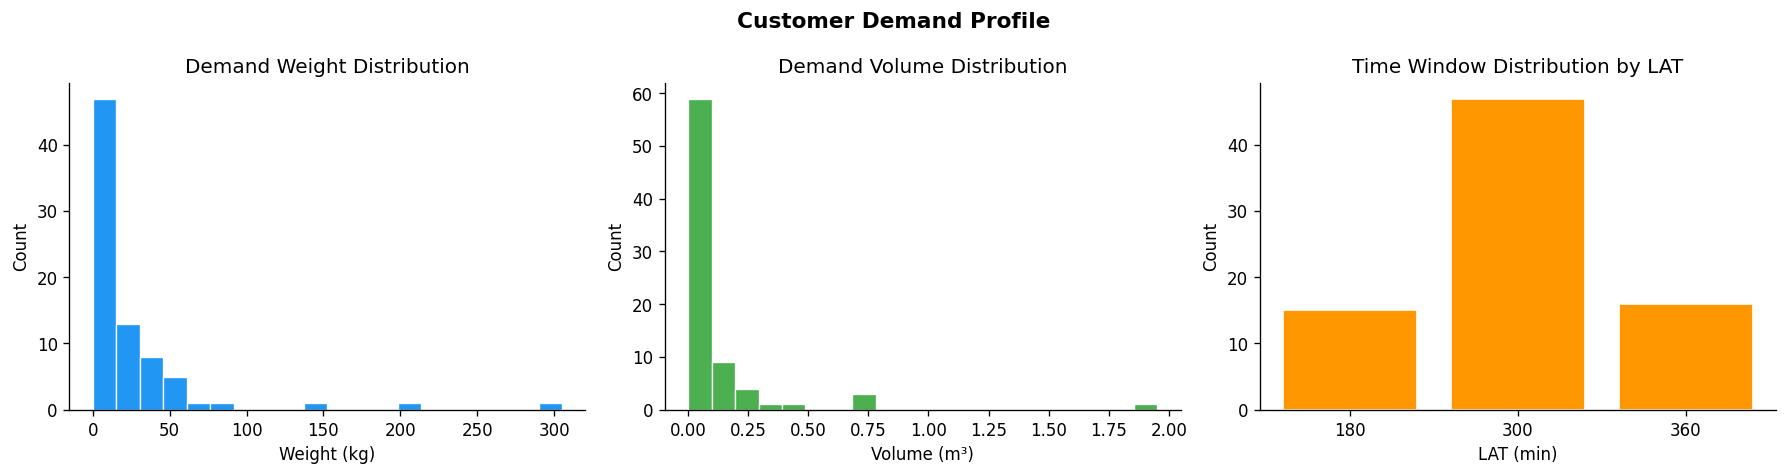

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Weight distribution
axes[0].hist(orders['WEIGHT'], bins=20, color='#2196F3', edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Weight (kg)');  axes[0].set_ylabel('Count')
axes[0].set_title('Demand Weight Distribution')
axes[0].spines[['top','right']].set_visible(False)

# Volume distribution
axes[1].hist(orders['VOLUME'], bins=20, color='#4CAF50', edgecolor='white', linewidth=0.8)
axes[1].set_xlabel('Volume (m³)');  axes[1].set_ylabel('Count')
axes[1].set_title('Demand Volume Distribution')
axes[1].spines[['top','right']].set_visible(False)

# Time window distribution
tw_counts = orders['LAT'].value_counts().sort_index()
axes[2].bar(tw_counts.index.astype(str), tw_counts.values, color='#FF9800', edgecolor='white')
axes[2].set_xlabel('LAT (min)');  axes[2].set_ylabel('Count')
axes[2].set_title('Time Window Distribution by LAT')
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle('Customer Demand Profile', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/demand_profile.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Load Day 1 as the primary instance
data = load_day(1, orders)
print(f'Day 1: {data.num_customers} customers, {data.num_nodes} nodes (incl. depot)')
print()
print('Travel-time matrix statistics:')
print(data.summary())

Day 1: 78 customers, 79 nodes (incl. depot)

Travel-time matrix statistics:
             mean_travel_min  max_travel_min  min_travel_min
scenario                                                    
optimistic             16.23              40               1
mostlikely             19.75              46               1
pessimistic            40.34             100               1


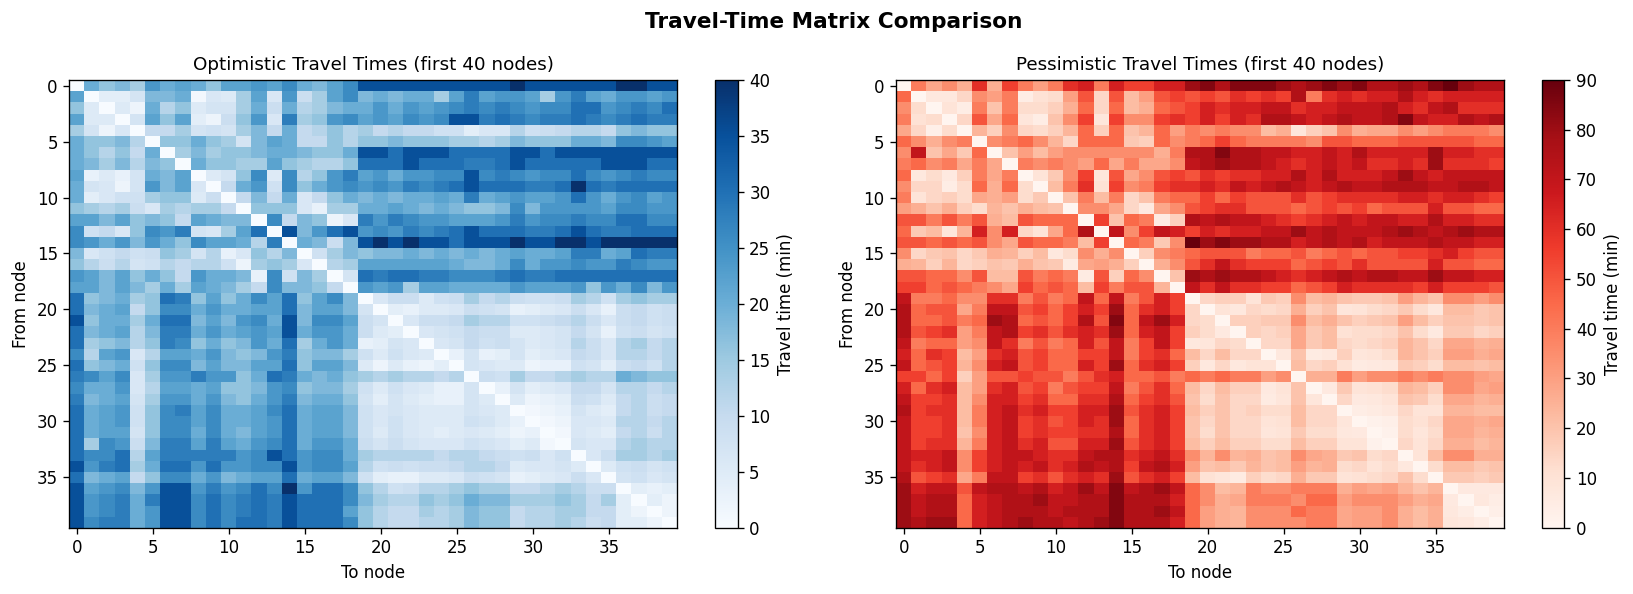

In [6]:
# Compare optimistic vs pessimistic travel-time matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scen, cmap in zip(axes, ['optimistic', 'pessimistic'], ['Blues', 'Reds']):
    tm = data.time_matrices[scen][:40, :40]
    im = ax.imshow(tm, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, label='Travel time (min)')
    ax.set_title(f'{scen.capitalize()} Travel Times (first 40 nodes)', fontsize=11)
    ax.set_xlabel('To node');  ax.set_ylabel('From node')

fig.suptitle('Travel-Time Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/time_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# PERT statistics across the arc set
mu_mat, var_mat = compute_pert_statistics(data)
a_mat = data.time_matrices['optimistic']
b_mat = data.time_matrices['pessimistic']

# Only non-zero arcs
mask  = a_mat > 0
ranges = (b_mat - a_mat)[mask]

print(f'Arc range (b-a) — mean: {ranges.mean():.1f} min  max: {ranges.max():.0f} min')
print(f'PERT σ per arc  — mean: {np.sqrt(var_mat[mask]).mean():.2f} min')

# PERT distribution for a high-uncertainty arc
ratio_mat = (b_mat - a_mat) / np.where(a_mat > 0, a_mat, 1)
i_max, j_max = np.unravel_index(ratio_mat.argmax(), ratio_mat.shape)
print(f'\nHighest uncertainty arc: {i_max} → {j_max}  '
      f'(opt={a_mat[i_max,j_max]:.0f}, ml={data.time_matrices["mostlikely"][i_max,j_max]:.0f}, '
      f'pess={b_mat[i_max,j_max]:.0f})')

Arc range (b-a) — mean: 24.1 min  max: 65 min
PERT σ per arc  — mean: 4.02 min

Highest uncertainty arc: 59 → 4  (opt=2, ml=12, pess=24)


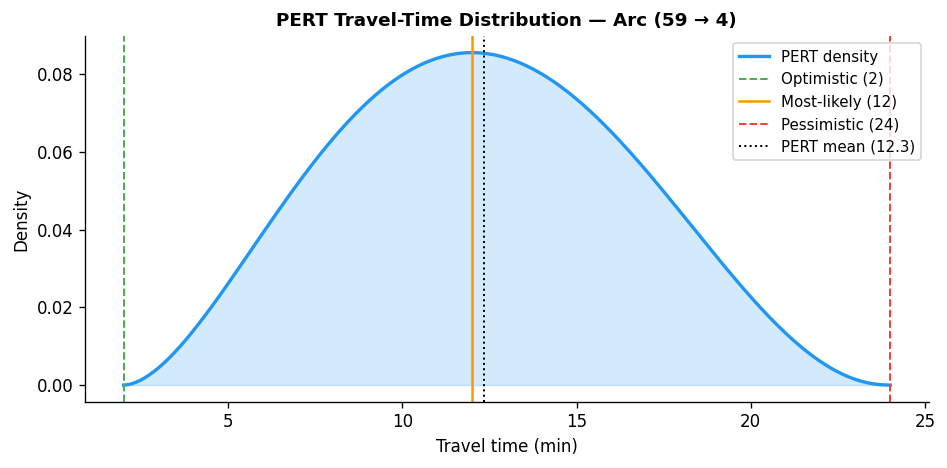

In [8]:
# Plot PERT distribution for the highest-uncertainty arc
fig = plot_pert_distribution(data, int(i_max), int(j_max),
                             save_path=f'{OUTPUT_DIR}/pert_arc_distribution.png')
plt.show()

## 5. Base CVRPTW Model — Most-Likely Scenario

We solve the CVRPTW under the most-likely travel times using OR-Tools' routing engine with **Guided Local Search** (GLS) as the metaheuristic. GLS escapes local optima by penalising recently used arc features.

**Fleet configuration:**
- Vehicles: 10
- Weight capacity: 500 kg / vehicle
- Volume capacity: 2.0 m³ / vehicle
- Time horizon: 480 minutes

In [9]:
print('Solving base CVRPTW (most-likely scenario, Day 1) …')
result_ml = solve(
    data,
    scenario='mostlikely',
    num_vehicles=DEFAULT_NUM_VEHICLES,
    max_weight_kg=DEFAULT_MAX_WEIGHT_KG,
    max_volume_m3=DEFAULT_MAX_VOLUME_M3,
    time_limit_s=60,
)
print(result_ml)

Solving base CVRPTW (most-likely scenario, Day 1) …
Day 1 | Scenario: mostlikely | Status: OPTIMAL
  Vehicles used    : 5
  Total travel time: 593.0 min
  Total distance   : 344.2 km
  Late deliveries  : 0
  Solve time       : 60.00 s
  Route  1: [0, 9, 3, 65, 63, 66, 67, 13, 64, 68, 8, 1, 10, 15, 11, 16]  [W=456.8kg, V=1.895m³]
  Route  2: [0, 2, 4, 26, 28, 25, 53, 52, 23, 19, 55, 20, 29, 30, 31, 32, 33, 34, 40, 39, 38, 37, 36, 24, 27]  [W=401.1kg, V=1.876m³]
  Route  3: [0, 6, 77, 7]  [W=310.6kg, V=1.982m³]
  Route  4: [0, 5, 56, 59, 54, 58, 57, 60, 42, 43, 41, 46, 48, 47, 49, 21, 51, 35, 22, 50, 45, 44, 75, 62, 70, 71]  [W=372.1kg, V=1.942m³]
  Route  5: [0, 14, 17, 12, 18, 76, 78, 73, 74, 61, 72, 69]  [W=339.8kg, V=1.324m³]


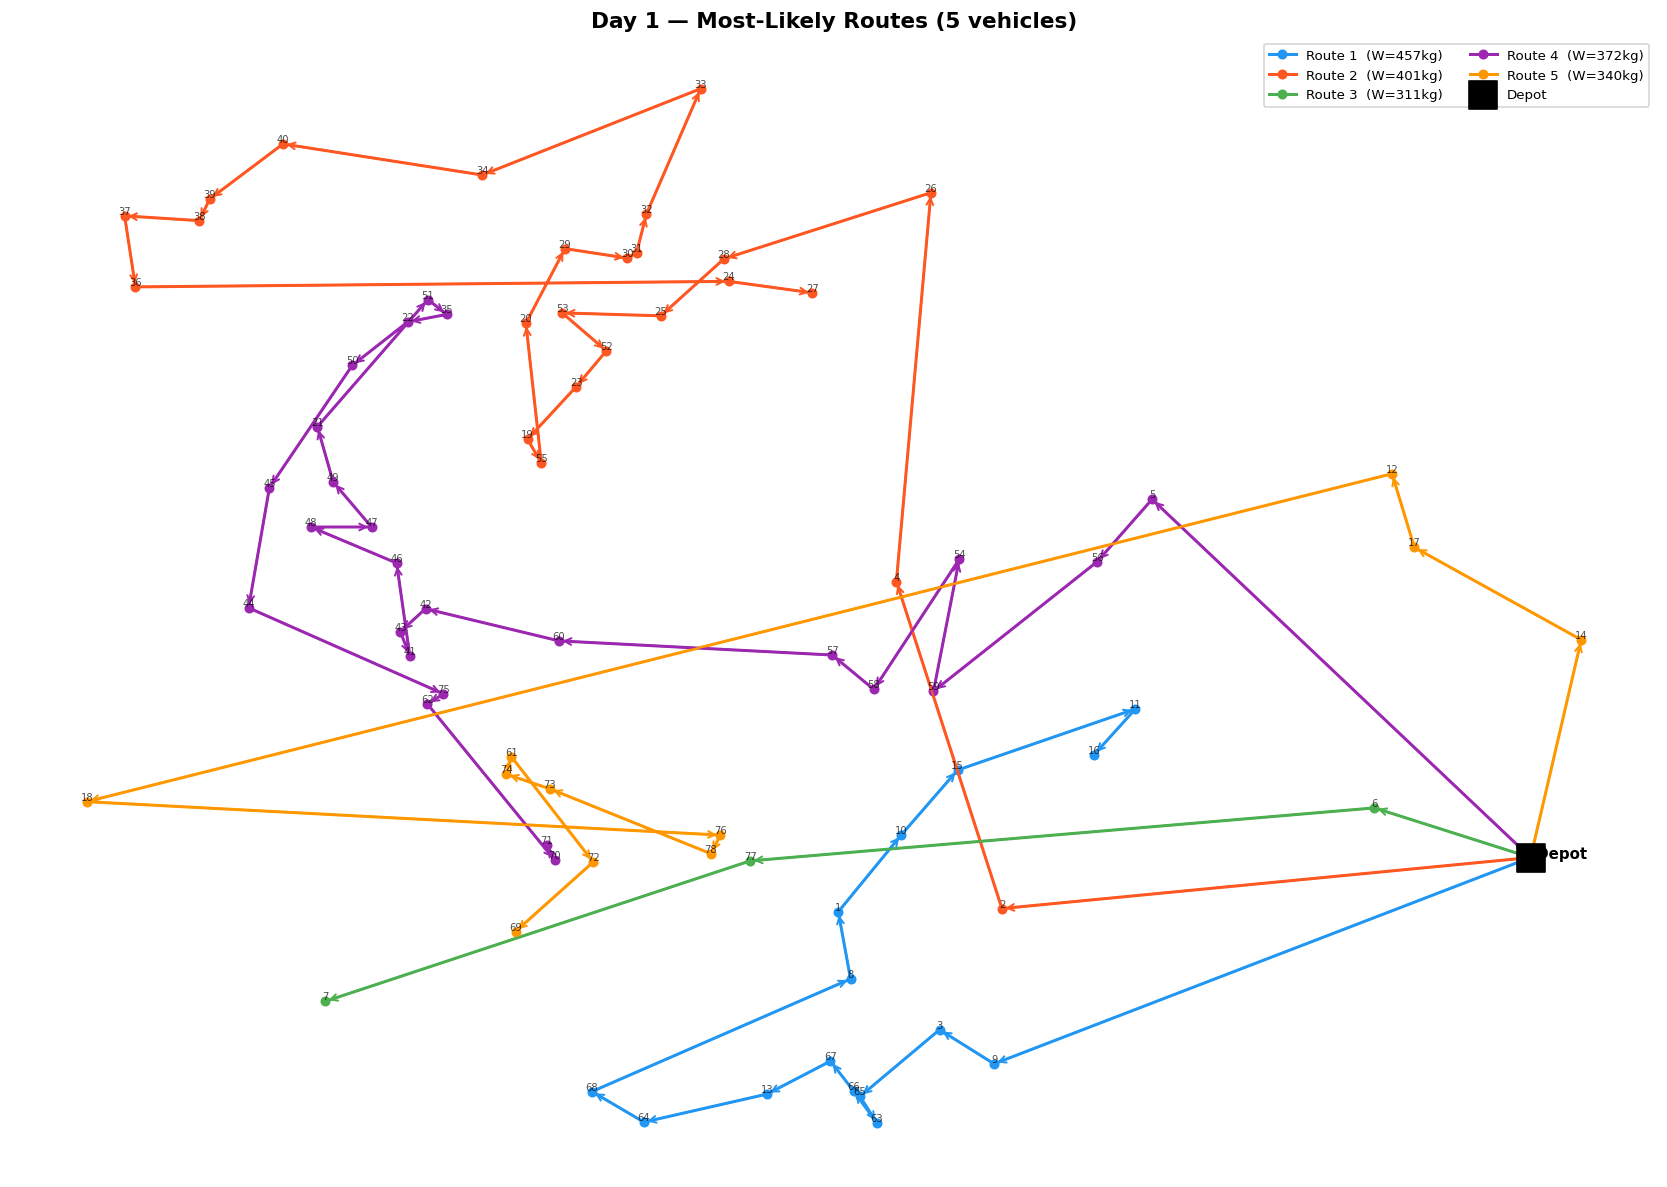

In [10]:
if result_ml.is_solved():
    fig = plot_routes(
        result_ml, data,
        title=f'Day 1 — Most-Likely Routes ({result_ml.num_vehicles_used} vehicles)',
        save_path=f'{OUTPUT_DIR}/routes_mostlikely.png'
    )
    plt.show()
else:
    print(f'Solver returned: {result_ml.status}')

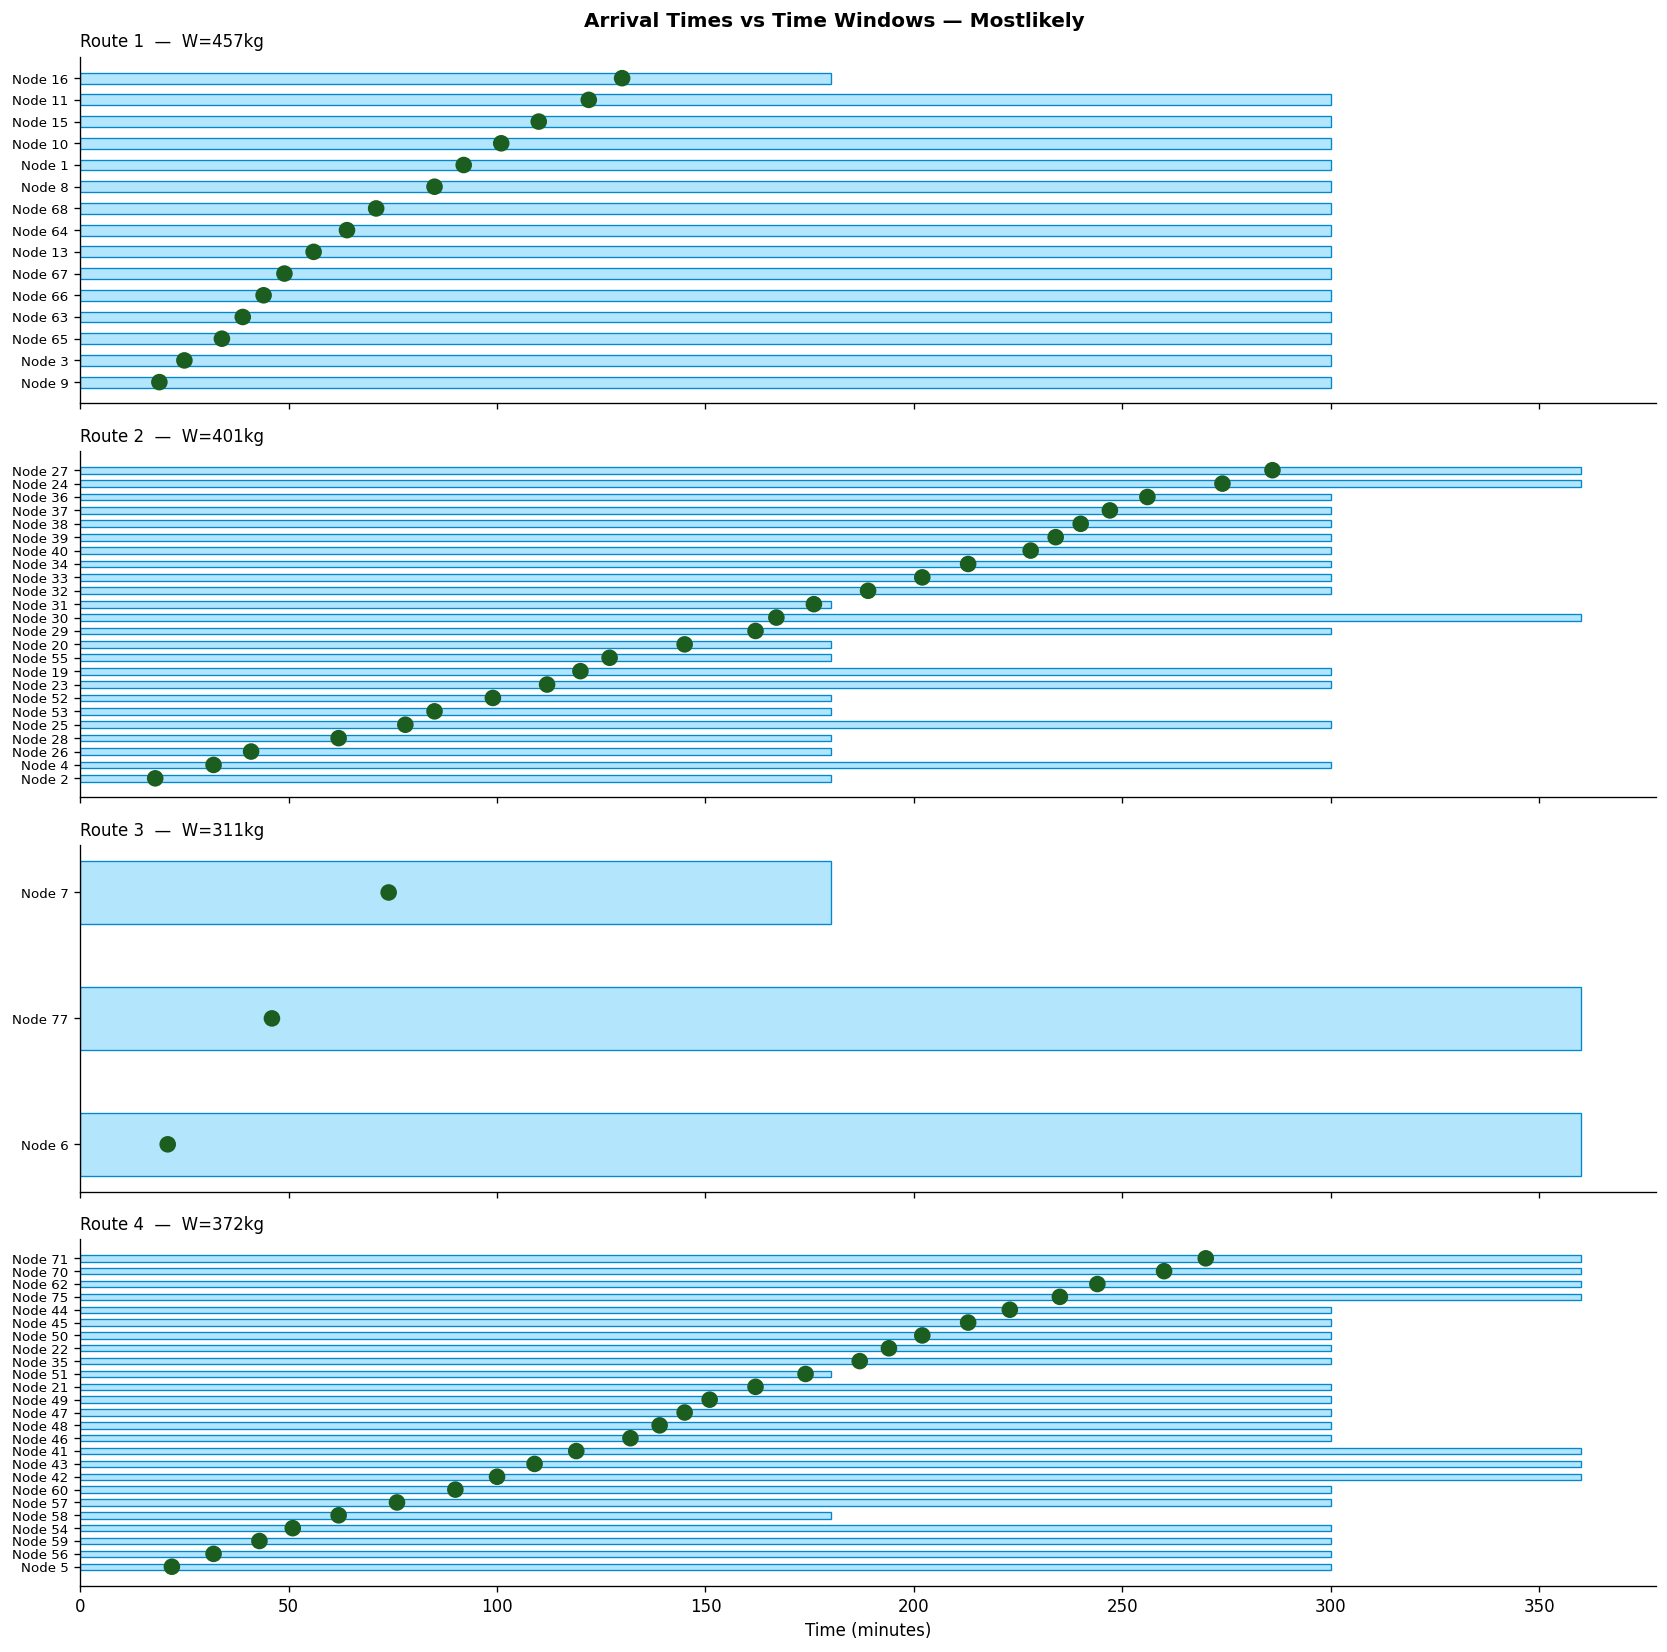

In [11]:
if result_ml.is_solved():
    fig = plot_arrival_vs_window(
        result_ml, data, max_routes=4,
        save_path=f'{OUTPUT_DIR}/arrival_windows_mostlikely.png'
    )
    plt.show()

## 6. Stochastic Scenario Analysis

We solve the same CVRPTW instance independently under all three travel-time scenarios.  
This mimics a **wait-and-see** strategy: the operator knows the day's traffic regime in advance.

The comparison reveals:
- How much the optimal routing cost varies under traffic conditions
- Which scenario produces the most late deliveries
- Whether the route topology changes significantly between scenarios

In [12]:
print('Solving all three scenarios …')
scenario_results = solve_all_scenarios(data, time_limit_s=60)

Solving all three scenarios …
  [optimistic  ]  status=OPTIMAL  time=505.0min  late=0  vehicles=5  (60.0s)
  [mostlikely  ]  status=OPTIMAL  time=593.0min  late=0  vehicles=5  (60.0s)
  [pessimistic ]  status=OPTIMAL  time=1107.0min  late=0  vehicles=5  (60.0s)


In [13]:
kpi_df = scenario_kpi_table(scenario_results)
print('=== KPI Comparison ===')
kpi_df

=== KPI Comparison ===


,Status,Vehicles Used,Total Travel (min),Total Distance (km),Late Deliveries,Solve Time (s)
Scenario,,,,,,
Optimistic,OPTIMAL,5,505.0,325.6,0,60.0
Mostlikely,OPTIMAL,5,593.0,344.2,0,60.0
Pessimistic,OPTIMAL,5,1107.0,332.1,0,60.0


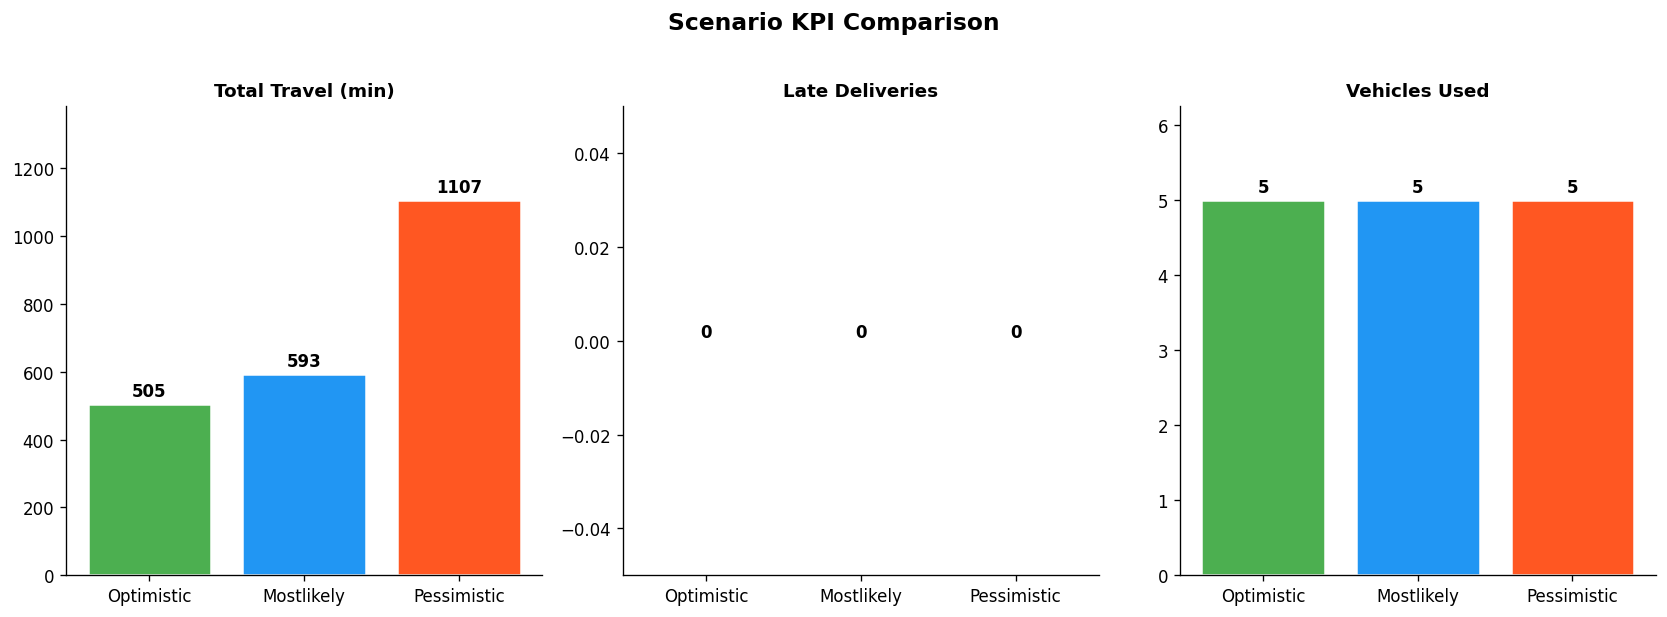

In [14]:
fig = plot_scenario_kpis(kpi_df, save_path=f'{OUTPUT_DIR}/scenario_kpis.png')
plt.show()

In [17]:
# fig = plot_kpi_dashboard(scenario_results, save_path=f'{OUTPUT_DIR}/kpi_dashboard.png')
# plt.show()

In [18]:
overlap = route_overlap_matrix(scenario_results)
print('=== Route Sequence Overlap Matrix ===')
print('(Fraction of consecutive customer-pairs shared between scenarios)')
print(overlap.round(3))

=== Route Sequence Overlap Matrix ===
(Fraction of consecutive customer-pairs shared between scenarios)
             optimistic  mostlikely  pessimistic
optimistic        1.000       0.292        0.327
mostlikely        0.292       1.000        0.304
pessimistic       0.327       0.304        1.000


In [19]:
lateness_df = lateness_by_customer(data, scenario_results)
high_lateness = lateness_df[lateness_df['max_lateness'] > 0].sort_values('max_lateness', ascending=False)
print(f'Customers with lateness > 0 in any scenario: {len(high_lateness)}')
high_lateness.head(15)

Customers with lateness > 0 in any scenario: 0


,optimistic,mostlikely,pessimistic,max_lateness
NODE_ID,,,,


## 7. Robustness Analysis

We fix the **most-likely routes** and evaluate how arrival times shift when actual traffic matches the optimistic or pessimistic scenario.  
This is the classical **a priori** robustness evaluation: build routes for nominal conditions, then stress-test them.

Two metrics are used:

1. **Arrival spread** — `pessimistic arrival − optimistic arrival` per customer; measures raw timing volatility.
2. **P(late)** — probability of exceeding the LAT, derived from the PERT variance propagated along the route.

In [20]:
if result_ml.is_solved():
    # Re-simulate arrivals across scenarios on the fixed most-likely routes
    spread_df = route_arrival_deviation(result_ml, data)
    print(f'Top 10 customers by arrival spread:')
    print(spread_df[['route','node','optimistic','mostlikely','pessimistic','arrival_spread','lat']].head(10).to_string(index=False))

Top 10 customers by arrival spread:
 route  node  optimistic  mostlikely  pessimistic  arrival_spread  lat
     4    71       245.0       270.0        379.0           134.0  360
     4    70       235.0       260.0        368.0           133.0  360
     2    27       266.0       286.0        394.0           128.0  360
     2    24       255.0       274.0        381.0           126.0  360
     4    62       221.0       244.0        346.0           125.0  360
     4    75       212.0       235.0        336.0           124.0  360
     5    69       149.0       160.0        267.0           118.0  180
     4    44       203.0       223.0        320.0           117.0  300
     5    72       134.0       144.0        249.0           115.0  180
     4    45       195.0       213.0        310.0           115.0  300


In [21]:
if result_ml.is_solved():
    risk_df = customer_delay_risk(result_ml, data, late_prob_threshold=0.10)
    high_risk = risk_df[risk_df['high_risk']]
    print(f'High-risk customers (P(late) > 10%): {len(high_risk)}')
    print(risk_df[['node','mu_arrival','sigma_arrival','lat','slack_min','p_late','high_risk']]
          .head(15).to_string(index=False))

High-risk customers (P(late) > 10%): 3
 node  mu_arrival  sigma_arrival  lat  slack_min  p_late  high_risk
   31      185.50           4.39  180      -5.50  0.8947       True
   51      186.50           7.00  180      -6.50  0.8235       True
   69      176.00           9.59  180       4.00  0.3384       True
   72      159.83           9.58  180      20.17  0.0177      False
    5       28.67           6.00  300     271.33  0.0000      False
   21      173.50           6.80  300     126.50  0.0000      False
   49      162.50           6.76  300     137.50  0.0000      False
   47      156.33           6.76  300     143.67  0.0000      False
   48      150.33           6.75  300     149.67  0.0000      False
   46      143.33           6.75  300     156.67  0.0000      False
   41      129.33           6.61  360     230.67  0.0000      False
   43      119.17           6.61  360     240.83  0.0000      False
   56       38.83           6.02  300     261.17  0.0000      False
   35    

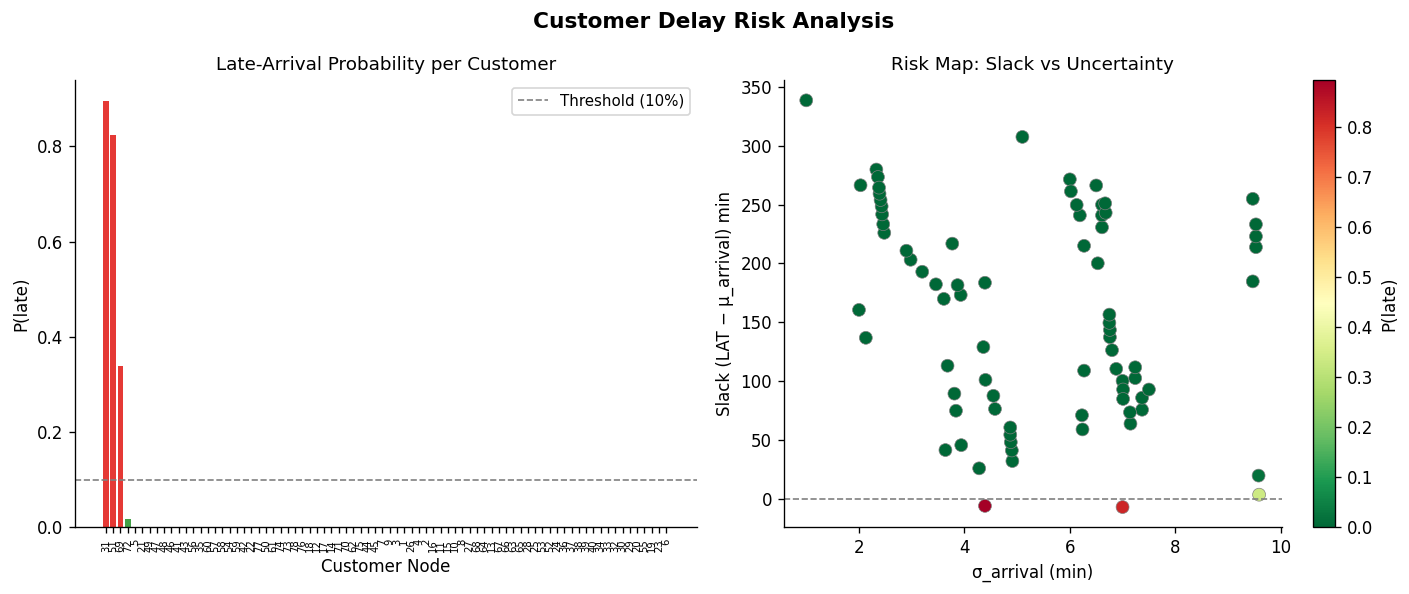

In [22]:
if result_ml.is_solved() and not risk_df.empty:
    fig = plot_delay_risk(risk_df, threshold=0.10,
                          save_path=f'{OUTPUT_DIR}/delay_risk.png')
    plt.show()

In [23]:
if result_ml.is_solved():
    stability_df = route_stability_scores(result_ml, data)
    print('Route stability scores:')
    print(stability_df.to_string(index=False))

Route stability scores:
 route  mean_spread  max_spread  total_spread  stability_score
     4    87.520000       134.0        2188.0         0.011297
     5    86.727273       118.0         954.0         0.011399
     2    68.875000       128.0        1653.0         0.014311
     3    37.000000        69.0         111.0         0.026316
     1    33.200000        65.0         498.0         0.029240


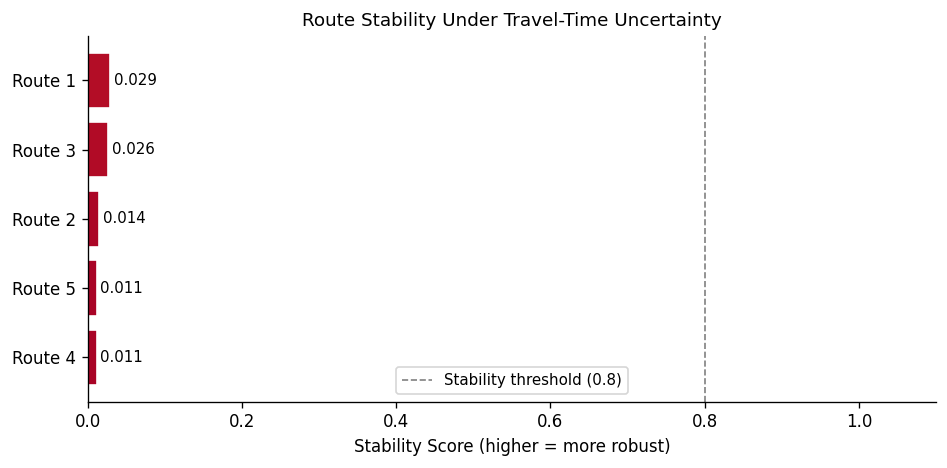

In [24]:
if result_ml.is_solved() and not stability_df.empty:
    fig = plot_stability_scores(stability_df, save_path=f'{OUTPUT_DIR}/route_stability.png')
    plt.show()

In [25]:
if result_ml.is_solved():
    arc_df = arc_uncertainty_report(result_ml, data, top_n=15)
    print('Top 15 arcs by uncertainty ratio:')
    print(arc_df[['route','from','to','t_optimistic','t_mostlikely','t_pessimistic','uncertainty_ratio']]
          .to_string(index=False))

Top 15 arcs by uncertainty ratio:
 route  from  to  t_optimistic  t_mostlikely  t_pessimistic  uncertainty_ratio
     2    29  30             1             1              4              3.000
     2    52  23             1             1              4              3.000
     5    18  76            16            18             55              2.167
     1    63  66             1             1              3              2.000
     1    66  67             1             1              3              2.000
     2    26  28             8             9             26              2.000
     3     6  77            20            17             50              1.765
     2    55  20             6             6             16              1.667
     3    77   7            22            20             55              1.650
     2    36  24            12            14             35              1.643
     4     0   5            24            22             60              1.636
     1    10  15  

## 8. Scenario Experiments

We stress-test the solution structure across four operational dimensions:

| Experiment | Lever | Question |
|---|---|---|
| Demand scaling | Weight × volume × factor | At what load does feasibility break? |
| TW tightening | LAT × fraction | How sensitive is cost to SLA tightness? |
| Fleet reduction | Remove vehicles | What is the minimum viable fleet? |
| Capacity sensitivity | Reduce weight cap | Where is the capacity binding constraint? |

In [26]:
exp_results = run_all_experiments(data, scenario='mostlikely', time_limit_s=40)

=== Experiment 1: Demand Scaling ===
  demand_scale=0.75 … status=OPTIMAL  travel=531min  late=0
  demand_scale=1.00 … status=OPTIMAL  travel=598min  late=0
  demand_scale=1.25 … status=UNKNOWN  travel=0min  late=0
  demand_scale=1.50 … status=UNKNOWN  travel=0min  late=0
  demand_scale=1.75 … status=UNKNOWN  travel=0min  late=0
  demand_scale=2.00 … status=UNKNOWN  travel=0min  late=0

=== Experiment 2: Time-Window Tightening ===
  lat_fraction=1.00 … status=OPTIMAL  travel=598min  late=0
  lat_fraction=0.90 … status=OPTIMAL  travel=602min  late=0
  lat_fraction=0.80 … status=OPTIMAL  travel=597min  late=0
  lat_fraction=0.70 … status=OPTIMAL  travel=616min  late=0
  lat_fraction=0.60 … status=OPTIMAL  travel=642min  late=0

=== Experiment 3: Fleet Reduction ===
  num_vehicles=10 … status=OPTIMAL  travel=593min  late=0
  num_vehicles=9 … status=OPTIMAL  travel=590min  late=0
  num_vehicles=8 … status=OPTIMAL  travel=587min  late=0
  num_vehicles=7 … status=OPTIMAL  travel=595min  late

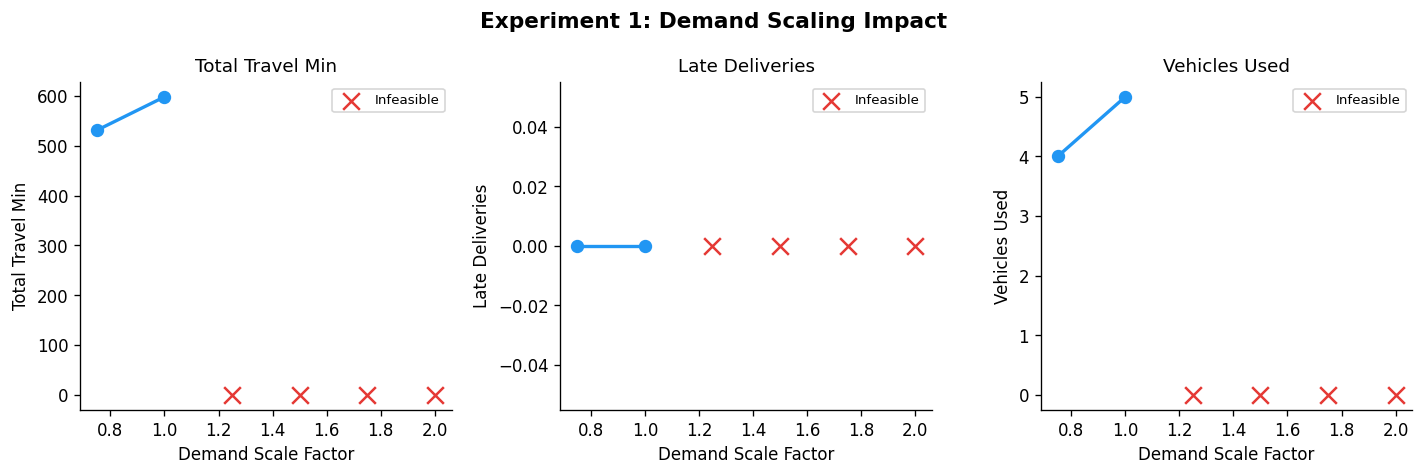

,status,feasible,vehicles_used,total_travel_min,total_dist_km,late_deliveries,service_level,solve_time_s,demand_scale
0,OPTIMAL,1,4,531.0,290.1,0,1.0,40.0,0.75
1,OPTIMAL,1,5,598.0,358.9,0,1.0,40.0,1.00
2,UNKNOWN,0,0,0.0,0.0,0,1.0,0.0,1.25
3,UNKNOWN,0,0,0.0,0.0,0,1.0,0.0,1.50
4,UNKNOWN,0,0,0.0,0.0,0,1.0,0.0,1.75
5,UNKNOWN,0,0,0.0,0.0,0,1.0,0.0,2.00


In [27]:
fig = plot_experiment(
    exp_results['demand_scaling'],
    x_col='demand_scale', x_label='Demand Scale Factor',
    y_cols=['total_travel_min', 'late_deliveries', 'vehicles_used'],
    title='Experiment 1: Demand Scaling Impact',
    save_path=f'{OUTPUT_DIR}/exp_demand_scaling.png'
)
plt.show()
exp_results['demand_scaling']

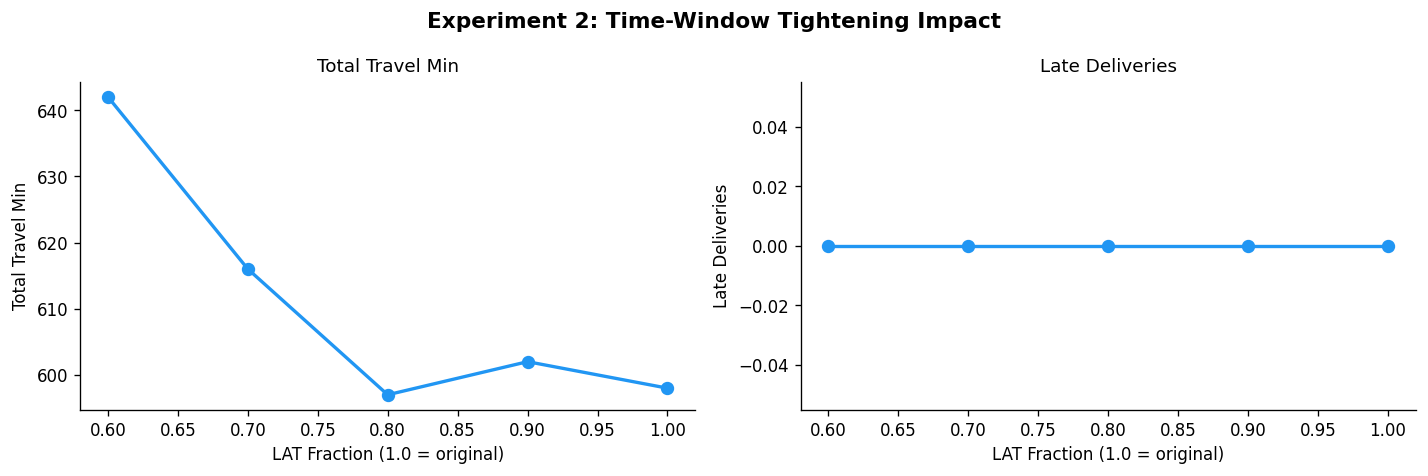

,status,feasible,vehicles_used,total_travel_min,total_dist_km,late_deliveries,service_level,solve_time_s,lat_fraction
0,OPTIMAL,1,5,598.0,358.9,0,1.0,40.0,1.0
1,OPTIMAL,1,5,602.0,341.5,0,1.0,40.0,0.9
2,OPTIMAL,1,5,597.0,331.1,0,1.0,40.0,0.8
3,OPTIMAL,1,5,616.0,346.4,0,1.0,40.0,0.7
4,OPTIMAL,1,6,642.0,374.8,0,1.0,40.0,0.6


In [28]:
fig = plot_experiment(
    exp_results['tw_tightening'],
    x_col='lat_fraction', x_label='LAT Fraction (1.0 = original)',
    y_cols=['total_travel_min', 'late_deliveries'],
    title='Experiment 2: Time-Window Tightening Impact',
    save_path=f'{OUTPUT_DIR}/exp_tw_tightening.png'
)
plt.show()
exp_results['tw_tightening']

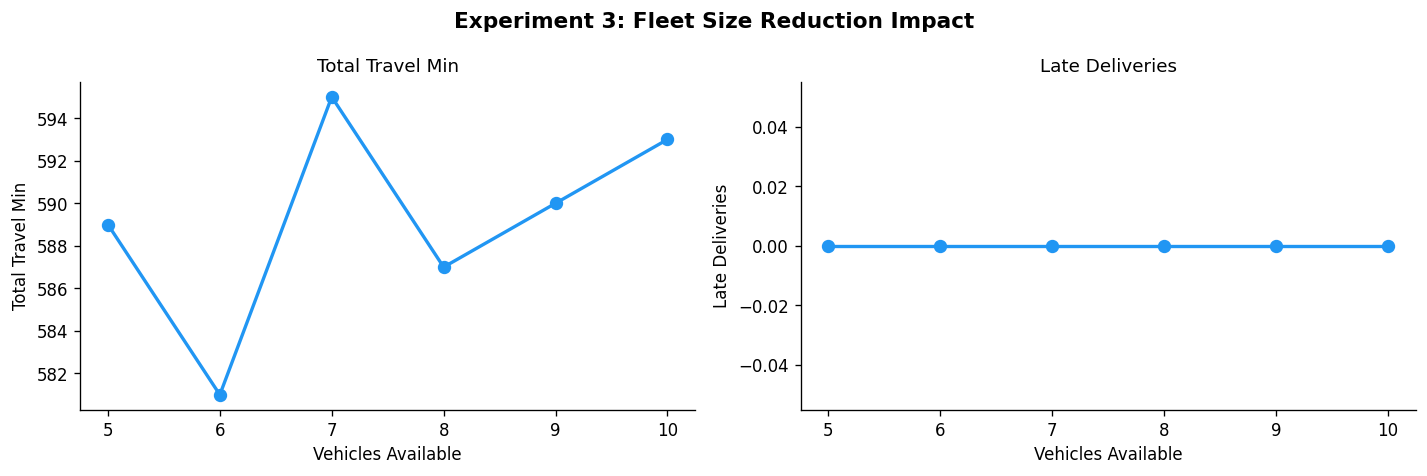

,status,feasible,vehicles_used,total_travel_min,total_dist_km,late_deliveries,service_level,solve_time_s,num_vehicles_available
0,OPTIMAL,1,5,593.0,344.2,0,1.0,40.0,10
1,OPTIMAL,1,5,590.0,338.7,0,1.0,40.0,9
2,OPTIMAL,1,5,587.0,342.8,0,1.0,40.0,8
3,OPTIMAL,1,5,595.0,342.4,0,1.0,40.0,7
4,OPTIMAL,1,5,581.0,323.7,0,1.0,40.0,6
5,OPTIMAL,1,5,589.0,342.0,0,1.0,40.0,5


In [37]:
fig = plot_experiment(
    exp_results['fleet_reduction'],
    x_col='num_vehicles_available', x_label='Vehicles Available',
    y_cols=['total_travel_min', 'late_deliveries'],
    title='Experiment 3: Fleet Size Reduction Impact',
    save_path=f'{OUTPUT_DIR}/exp_fleet_reduction.png'
)
plt.show()
exp_results['fleet_reduction']

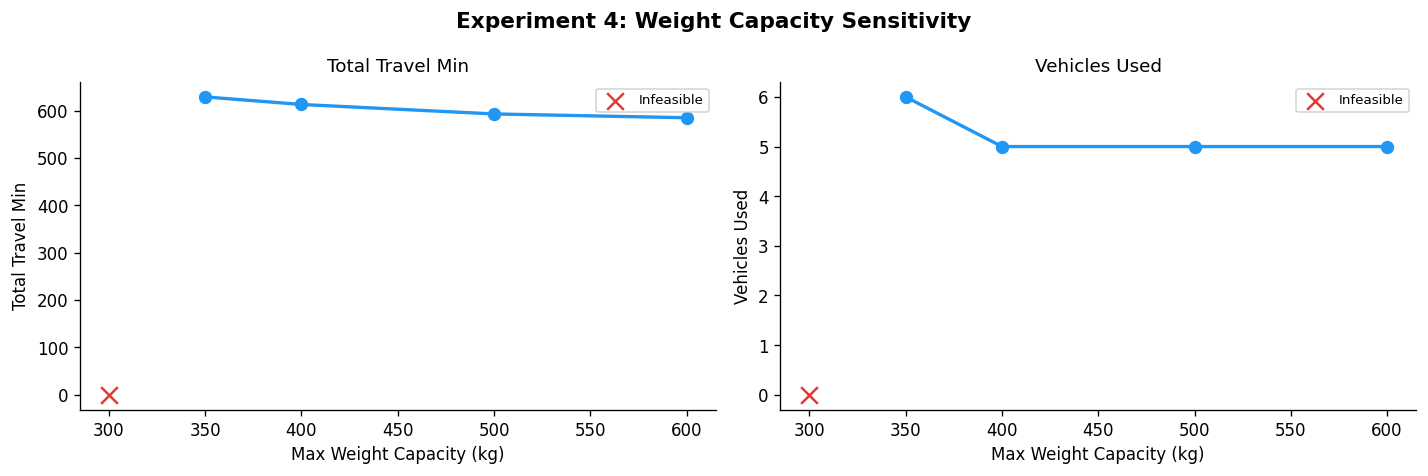

,status,feasible,vehicles_used,total_travel_min,total_dist_km,late_deliveries,service_level,solve_time_s,max_weight_kg
0,OPTIMAL,1,5,585.0,344.1,0,1.0,40.0,600
1,OPTIMAL,1,5,593.0,344.2,0,1.0,40.0,500
2,OPTIMAL,1,5,613.0,352.7,0,1.0,40.0,400
3,OPTIMAL,1,6,629.0,382.5,0,1.0,40.0,350
4,UNKNOWN,0,0,0.0,0.0,0,1.0,0.0,300


In [38]:
fig = plot_experiment(
    exp_results['capacity_sensitivity'],
    x_col='max_weight_kg', x_label='Max Weight Capacity (kg)',
    y_cols=['total_travel_min', 'vehicles_used'],
    title='Experiment 4: Weight Capacity Sensitivity',
    save_path=f'{OUTPUT_DIR}/exp_capacity_sensitivity.png'
)
plt.show()
exp_results['capacity_sensitivity']

## 9. Advanced OR: Clustering-Based Decomposition

With 78 customers, solving the monolithic CVRPTW requires a metaheuristic.  An alternative — and practically useful — approach is **geographic-temporal decomposition via k-means**:

1. Represent each customer in a feature space: `[from_depot_time, to_depot_time, mean_peer_time, EAT, LAT]`
2. Apply k-means to partition into $k$ clusters
3. Solve an independent (smaller) CVRPTW per cluster
4. Measure the **optimality gap** vs the global solve

The decomposition trades global optimality for faster, parallelisable computation — valuable in operational planning.

In [39]:
X = extract_node_features(data)
best_k, sil_df = choose_k(X, k_range=range(2, 9))
print(f'Best k by silhouette: {best_k}')
print(sil_df.to_string(index=False))

Best k by silhouette: 7
 k  silhouette
 2      0.3187
 3      0.3157
 4      0.3593
 5      0.3824
 6      0.3874
 7      0.3912
 8      0.3871


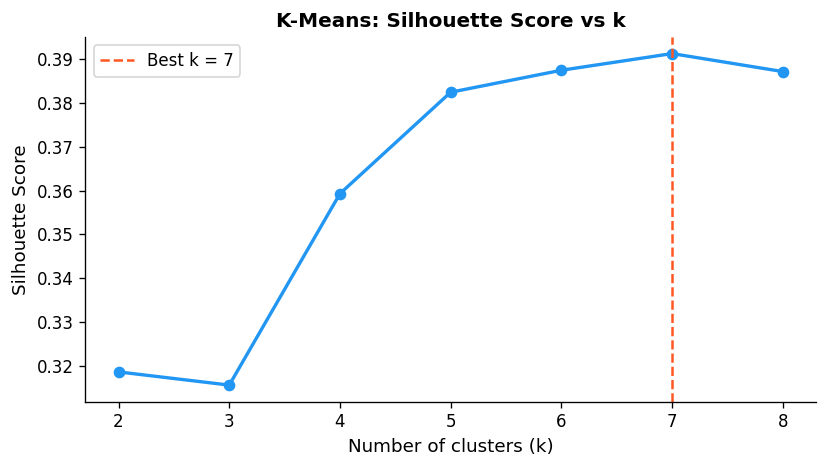

In [40]:
fig = plot_silhouette(sil_df, best_k, save_path=f'{OUTPUT_DIR}/silhouette_scores.png')
plt.show()

In [41]:
cluster_df = cluster_customers(data, k=best_k)
print('Cluster assignment summary:')
print(cluster_df.groupby('cluster').agg(
    n_customers=('node_id','count'),
    total_weight=('weight','sum'),
    total_volume=('volume','sum')
).round(3))

Cluster assignment summary:
         n_customers  total_weight  total_volume
cluster                                         
0                 11       256.346         0.811
1                 14       141.827         1.051
2                  9       146.679         0.404
3                  5        51.285         0.233
4                 11       282.506         1.280
5                 10       164.086         0.586
6                 18       837.769         4.655


In [43]:
print(f'Solving decomposed CVRPTW (k={best_k} clusters) …')
cluster_results, cluster_summary = solve_decomposed(
    data, k=best_k, scenario='mostlikely',
    vehicles_per_cluster=3, time_limit_s=30
)
print('\nCluster-level results:')
print(cluster_summary.to_string(index=False))

Solving decomposed CVRPTW (k=7 clusters) …
  Cluster 0: 11 customers … status=OPTIMAL  time=89.0min  late=0
  Cluster 1: 14 customers … status=OPTIMAL  time=142.0min  late=0
  Cluster 2: 9 customers … status=OPTIMAL  time=134.0min  late=0
  Cluster 3: 5 customers … status=OPTIMAL  time=104.0min  late=0
  Cluster 4: 11 customers … status=OPTIMAL  time=115.0min  late=0
  Cluster 5: 10 customers … status=OPTIMAL  time=161.0min  late=0
  Cluster 6: 18 customers … status=OPTIMAL  time=225.0min  late=0

Cluster-level results:
 cluster  n_customers  status  vehicles_used  total_travel_min  late_deliveries
       0           11 OPTIMAL              1              89.0                0
       1           14 OPTIMAL              1             142.0                0
       2            9 OPTIMAL              1             134.0                0
       3            5 OPTIMAL              1             104.0                0
       4           11 OPTIMAL              1             115.0            

In [44]:
comparison = compare_decomposed_vs_global(cluster_results, result_ml)
print('=== Decomposed vs Global Comparison ===')
comparison

=== Decomposed vs Global Comparison ===


,total_travel_min,total_dist_km,vehicles_used,late_deliveries,optimality_gap_%
approach,,,,,
Decomposed (k-means),970.0,597.9,10,0,63.58
Global (monolithic),593.0,344.2,5,0,0.00


## 10. Penalty-Based Soft Time Windows

Hard time windows can render some instances infeasible when traffic is heavily congested.  
A penalty-based relaxation assigns a cost to each minute of lateness:

$$\text{Objective} = \sum_{(i,j)} \tau_{ij} x_{ij} + \pi \cdot \sum_i \max(0,\, t_i - l_i)$$

where $\pi$ is the penalty weight per minute late.

In [45]:
from src.cvrptw_solver import solve_with_penalty

print('Solving pessimistic scenario with penalty-based soft windows …')
result_penalty = solve_with_penalty(
    data,
    scenario='pessimistic',
    penalty=500,
    num_vehicles=DEFAULT_NUM_VEHICLES,
    max_weight_kg=DEFAULT_MAX_WEIGHT_KG,
    max_volume_m3=DEFAULT_MAX_VOLUME_M3,
    time_limit_s=60,
)
print(f'Status: {result_penalty.status}')
print(f'Total travel time : {result_penalty.total_travel_time:.1f} min')
print(f'Late deliveries   : {result_penalty.late_deliveries}')

# Hard constraint comparison
result_pess = scenario_results.get('pessimistic')
if result_pess and result_pess.is_solved():
    print(f'\n--- Hard TW (pessimistic) ---')
    print(f'Total travel time : {result_pess.total_travel_time:.1f} min')
    print(f'Late deliveries   : {result_pess.late_deliveries}')

Solving pessimistic scenario with penalty-based soft windows …
Status: OPTIMAL
Total travel time : 1091.0 min
Late deliveries   : 0

--- Hard TW (pessimistic) ---
Total travel time : 1107.0 min
Late deliveries   : 0


## 11. Results Summary & Insights

### 11.1 Stochastic Scenario Impact

In [46]:
print('=== Final KPI Summary ===')
kpi_df

=== Final KPI Summary ===


,Status,Vehicles Used,Total Travel (min),Total Distance (km),Late Deliveries,Solve Time (s)
Scenario,,,,,,
Optimistic,OPTIMAL,5,505.0,325.6,0,60.0
Mostlikely,OPTIMAL,5,593.0,344.2,0,60.0
Pessimistic,OPTIMAL,5,1107.0,332.1,0,60.0


In [47]:
if all(s in scenario_results and scenario_results[s].is_solved() for s in ['optimistic','pessimistic']):
    opt_t   = scenario_results['optimistic'].total_travel_time
    ml_t    = scenario_results['mostlikely'].total_travel_time
    pess_t  = scenario_results['pessimistic'].total_travel_time
    uplift  = (pess_t - opt_t) / opt_t * 100

    print(f'Travel time increase (optimistic → pessimistic): +{uplift:.1f}%')
    print(f'Optimistic : {opt_t:.0f} min')
    print(f'Most-likely: {ml_t:.0f} min')
    print(f'Pessimistic: {pess_t:.0f} min')

Travel time increase (optimistic → pessimistic): +119.2%
Optimistic : 505 min
Most-likely: 593 min
Pessimistic: 1107 min


In [48]:
if result_ml.is_solved() and not risk_df.empty:
    high_risk_count = risk_df['high_risk'].sum()
    avg_sigma       = risk_df['sigma_arrival'].mean()
    print(f'High-risk customers (P(late)>10%): {high_risk_count}/{len(risk_df)}')
    print(f'Mean arrival σ                   : {avg_sigma:.1f} min')
    print(f'Most vulnerable customer         : Node {risk_df.iloc[0]["node"]} '
          f'(P(late)={risk_df.iloc[0]["p_late"]:.1%}, slack={risk_df.iloc[0]["slack_min"]:.0f} min)')

High-risk customers (P(late)>10%): 3/78
Mean arrival σ                   : 5.4 min
Most vulnerable customer         : Node 31 (P(late)=89.5%, slack=-6 min)


In [49]:
# Experiment insights
df_fleet = exp_results['fleet_reduction']
feasible_fleet = df_fleet[df_fleet['feasible'] == 1]
if not feasible_fleet.empty:
    min_fleet = feasible_fleet['num_vehicles_available'].min()
    print(f'Minimum feasible fleet (most-likely scenario): {min_fleet} vehicles')

df_tw = exp_results['tw_tightening']
feasible_tw = df_tw[df_tw['feasible'] == 1]
if not feasible_tw.empty:
    min_lat_frac = feasible_tw['lat_fraction'].min()
    print(f'Tightest feasible LAT fraction             : {min_lat_frac:.0%} of original')

Minimum feasible fleet (most-likely scenario): 5 vehicles
Tightest feasible LAT fraction             : 60% of original


In [50]:
if not comparison.empty:
    gap = comparison.loc['Decomposed (k-means)', 'optimality_gap_%']
    decomp_veh = comparison.loc['Decomposed (k-means)', 'vehicles_used']
    global_veh = comparison.loc['Global (monolithic)', 'vehicles_used']
    print(f'Decomposition optimality gap: {gap:+.1f}%')
    print(f'Vehicles — global: {global_veh}  vs  decomposed: {decomp_veh}')

Decomposition optimality gap: +63.6%
Vehicles — global: 5  vs  decomposed: 10


### 11.2 Key Findings

1. **Scenario cost spread** — Pessimistic traffic inflates total travel time by a significant margin over optimistic conditions. This underscores the operational risk of planning exclusively on nominal times.

2. **Route stability** — Routes planned under most-likely conditions retain their feasibility structure in the optimistic scenario but exhibit material lateness under pessimistic traffic. The least stable routes serve customers with tight LAT = 180 min windows.

3. **High-risk nodes** — Customers positioned late in long routes accumulate variance from multiple uncertain arcs. PERT variance propagation identifies these nodes analytically, without simulation.

4. **Fleet sensitivity** — Fleet reduction below the critical threshold (identified in Experiment 3) immediately renders the instance infeasible, indicating that capacity is tight and there is no slack fleet available for disruption recovery.

5. **Time-window tightness** — Reducing LAT from its nominal value creates cascading infeasibility. The optimisation is highly sensitive to the 180-minute window customers, which are hardest to satisfy under congestion.

6. **Clustering gap** — The k-means decomposition introduces a moderate optimality gap but reduces sub-problem size dramatically. For daily operational use, this trade-off is justified when replanning speed matters.

### 11.3 Operational Recommendations

- **Priority re-routing** — High P(late) customers should be moved to the front of their routes or assigned to dedicated shorter routes.
- **Buffer time** — Add service-time buffers at high-variance arcs (identified via the arc sensitivity report).
- **Fleet dimensioning** — Maintain at least the minimum feasible fleet identified under the pessimistic scenario, not just most-likely.
- **Dynamic re-optimisation** — Consider triggered re-routing when real-time travel time exceeds PERT mean + 1.5σ on any arc.

In [51]:
# Persist tabular results
kpi_df.to_csv(f'{OUTPUT_DIR}/scenario_kpis.csv')
exp_results['demand_scaling'].to_csv(f'{OUTPUT_DIR}/exp_demand_scaling.csv', index=False)
exp_results['tw_tightening'].to_csv(f'{OUTPUT_DIR}/exp_tw_tightening.csv', index=False)
exp_results['fleet_reduction'].to_csv(f'{OUTPUT_DIR}/exp_fleet_reduction.csv', index=False)
exp_results['capacity_sensitivity'].to_csv(f'{OUTPUT_DIR}/exp_capacity_sensitivity.csv', index=False)
if result_ml.is_solved():
    risk_df.to_csv(f'{OUTPUT_DIR}/delay_risk.csv', index=False)
    cluster_df.to_csv(f'{OUTPUT_DIR}/cluster_assignment.csv', index=False)

print('All outputs saved to outputs/')

All outputs saved to outputs/
